In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot, kdeplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, GORDO, wrapper_hierarchical
from inference_utils import get_prior
import warnings
warnings.simplefilter('ignore', FutureWarning)


# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize
    matplotlib.rcParams['axes.labelsize'] = fontsize
    matplotlib.rcParams['legend.fontsize'] = fontsize
    matplotlib.rcParams['figure.titlesize'] = fontsize


In [2]:
%%time
prior = get_prior('GORDO')
th = torch.tensor([-6.5,-1.1])
X = wrapper(GORDO, parameters=th, reps=10)

with open('posterior_2p.pkl', 'rb') as f:
    posterior = pickle.load(f)

epsilon = -100
Xs = torch.tensor(X)
op = CollectivePosterior(prior, Xs, posterior, 1, epsilon, n_eval=100000)

print(op.get_log_C())
print(op.log_prob(th))
est = op.sample(1000).mean(0)
est

<timed exec>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


tensor(25.8762)
tensor([0.9746])


Rejection Sampling: 1741it [00:00, 2227.58it/s]                         

CPU times: user 3min 32s, sys: 8.76 s, total: 3min 41s
Wall time: 4.93 s


tensor([-6.1483, -1.1882])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


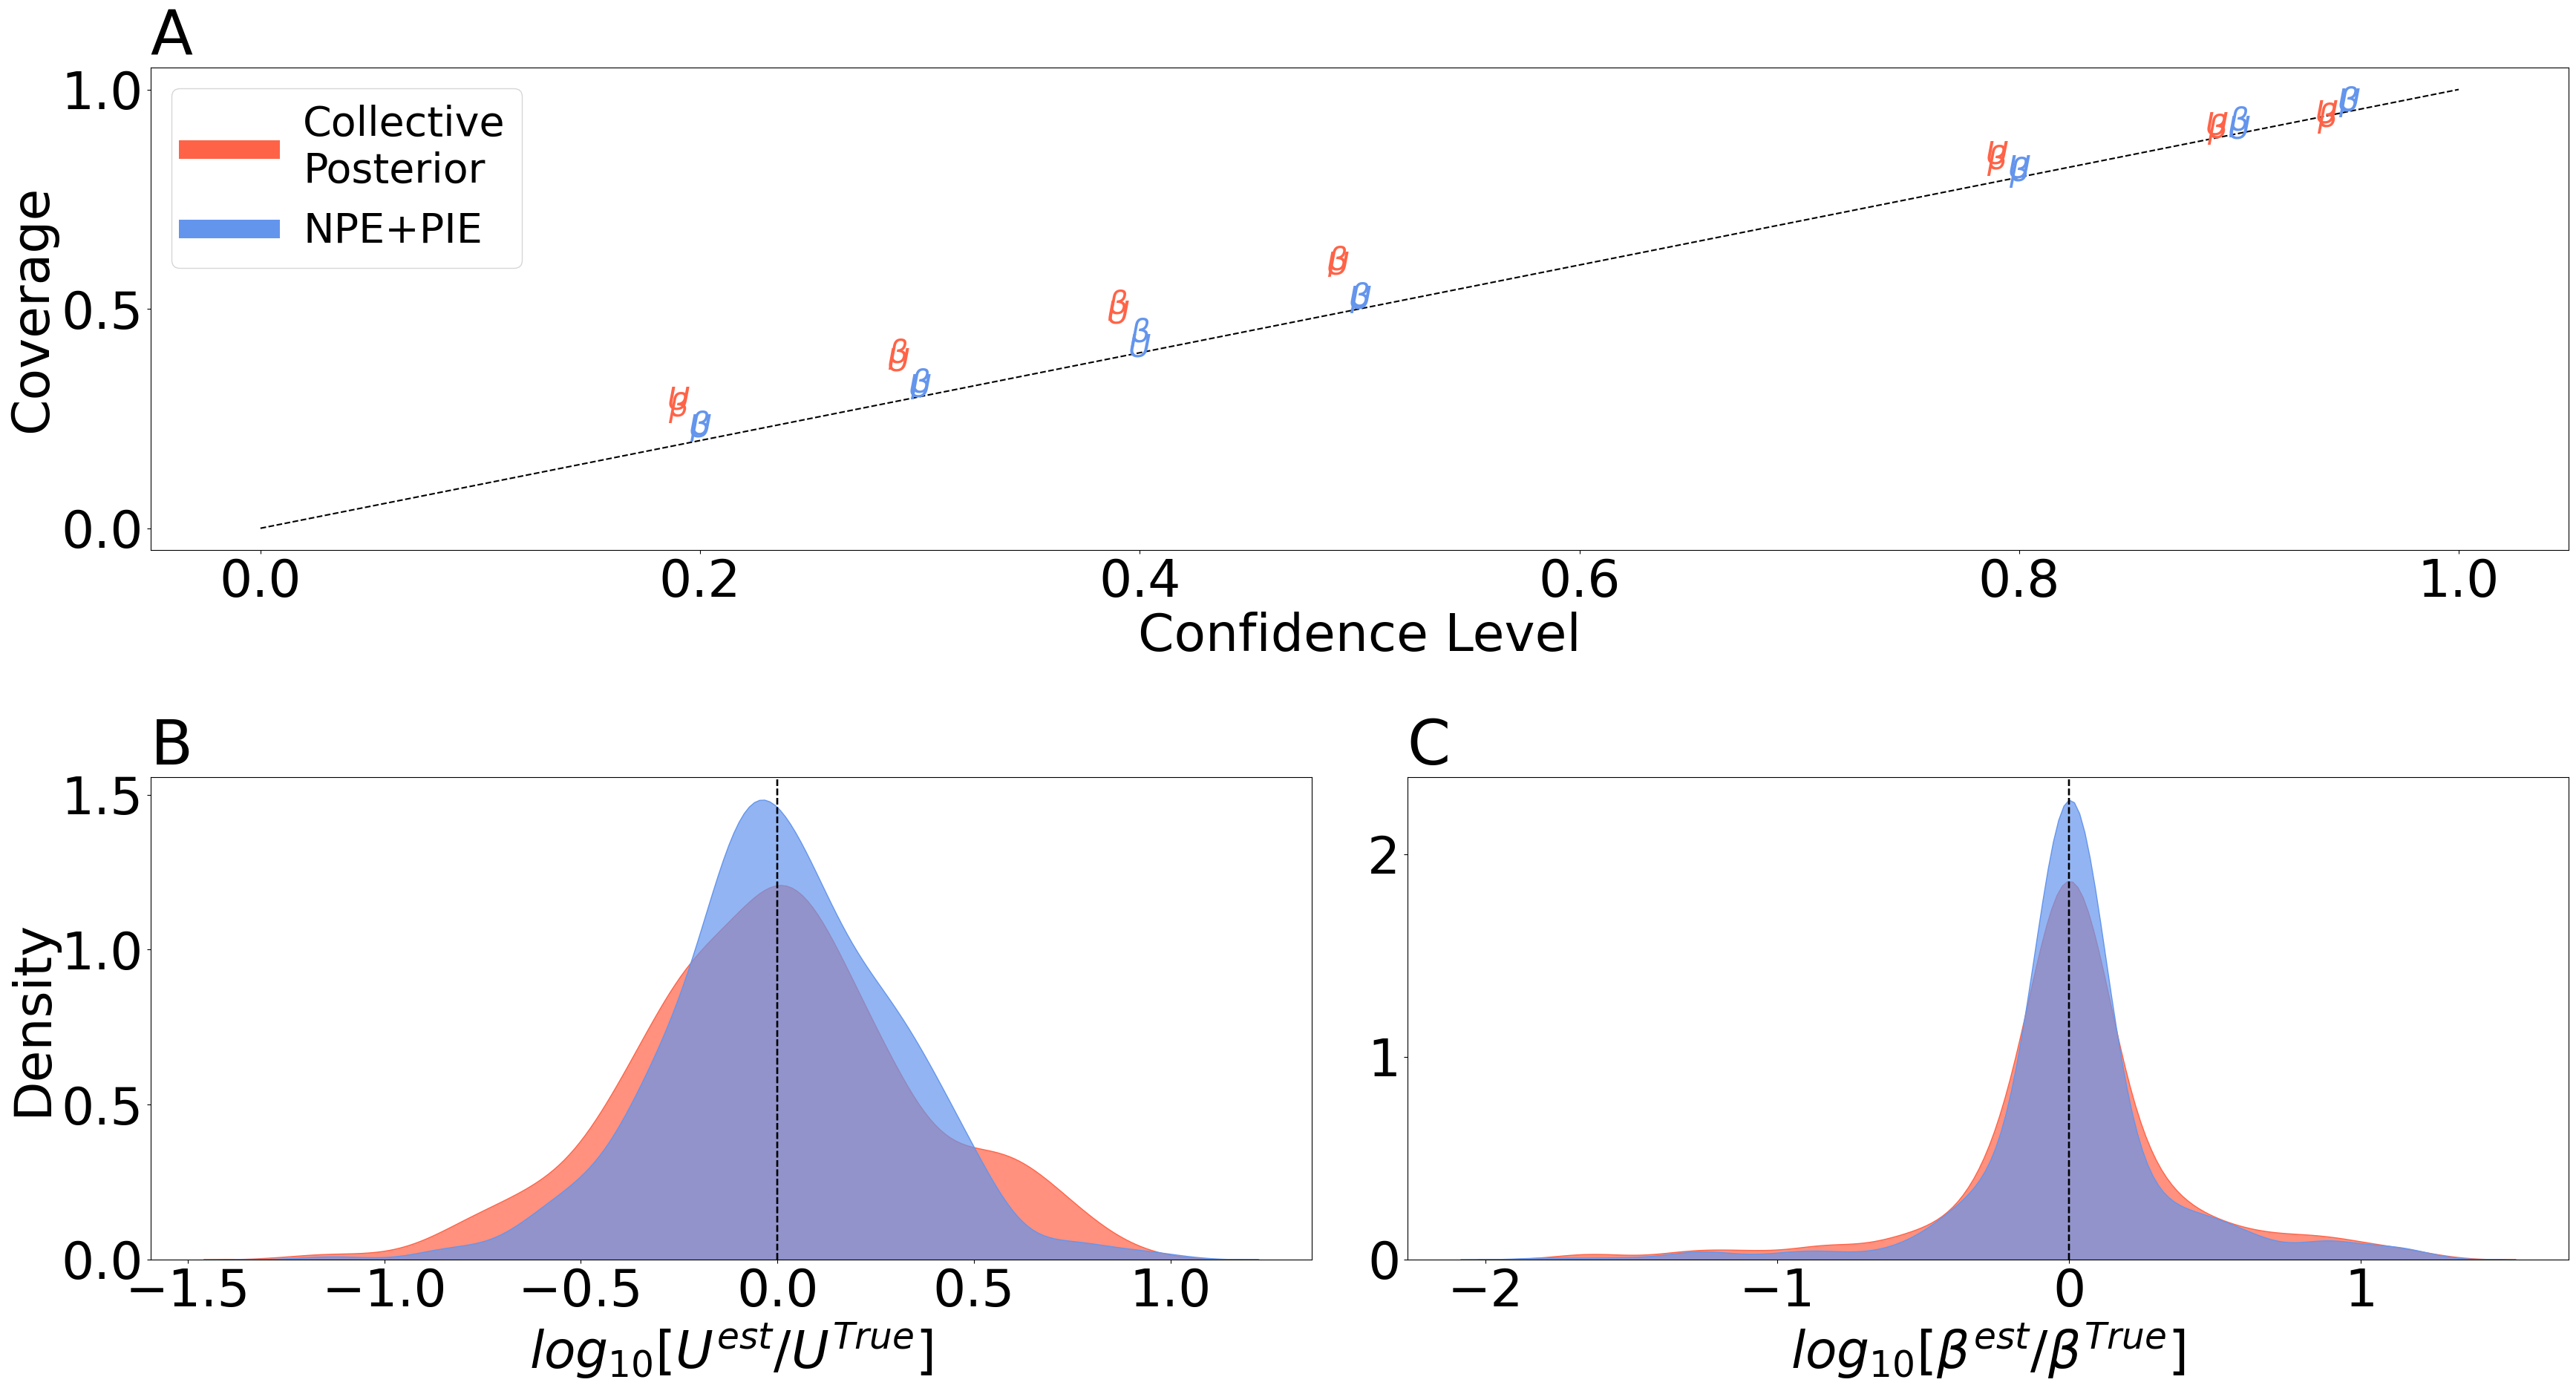

In [22]:
change_font(50)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        # histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=20, label=label, hatch=hatch)
        kdeplot(res[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs_old(ax, covs, color, label, cp=False):
    param_names = ['$U$', '$\\beta$']
    adjust=-0.01 if cp else 0
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            ax.text(covs.index[j]+adjust, covs[p].values[j], word, color=color, fontsize=30, ha='center', va='bottom')
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=400)
        
def tensor_cdf(tensor):
    """
    Given a 1D torch tensor or numpy array, returns (sorted_values, cdf_values) for plotting.
    """
    if isinstance(tensor, torch.Tensor):
        arr = tensor.detach().cpu().numpy().flatten()
    else:
        arr = np.asarray(tensor).flatten()
    sorted_vals = np.sort(arr)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    return sorted_vals, cdf

def plot_covs_cdf(ax, covs, color, label):
    """
    Plot the CDF of each column in covs (DataFrame or tensor) on the given axis.
    """
    param_names = ['$log U$', '$log \\beta$']
    if hasattr(covs, 'columns'):
        columns = covs.columns
    else:
        columns = range(covs.shape[1])
    for i, p in enumerate(columns):
        vec = covs[p] if hasattr(covs, 'columns') else covs[:,i]
        sorted_vals, cdf = tensor_cdf(vec)
        ax.plot(sorted_vals, cdf, label=param_names[i] if i < len(param_names) else str(p), color=color)
    ax.legend()
    ax.set_xlabel('Value')
    ax.set_ylabel('CDF')
    ax.set_title(label)

    ax.set_ylabel('Density')


# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AA
            BC
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')


# Coverage plots in ax B
ax['A'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_GORDO_r_.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_,label='Collective\nPosterior',color='tomato', cp=True)
covs_iid = pd.read_csv(f'tests/covs_old_GORDO_iid_r_.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue')
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)

# Accuracy plots in ax B-C
n_params=2
ax['B'].set_xlabel('$log_{10}[U^{est} / {U^{True}}]$')
ax['C'].set_xlabel('$log_{10}[\\beta^{est} / {\\beta^{True}}]$')

axx = [ax['B'], ax['C']]

cp_acc = 'tests/accus_GORDO_r_.csv'
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = 'tests/accus_GORDO_iid_r_.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['C'].set_ylabel('')

# Legend
from matplotlib.lines import Line2D
legend_elements = []
legend_elements.append(Line2D([0], [0], color='tomato', lw=18, label='Collective\nPosterior'))
legend_elements.append(Line2D([0], [0], color='cornflowerblue', lw=18, label='NPE+PIE'))
ax['A'].legend(handles=legend_elements, loc='upper left', fontsize=40)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, '')

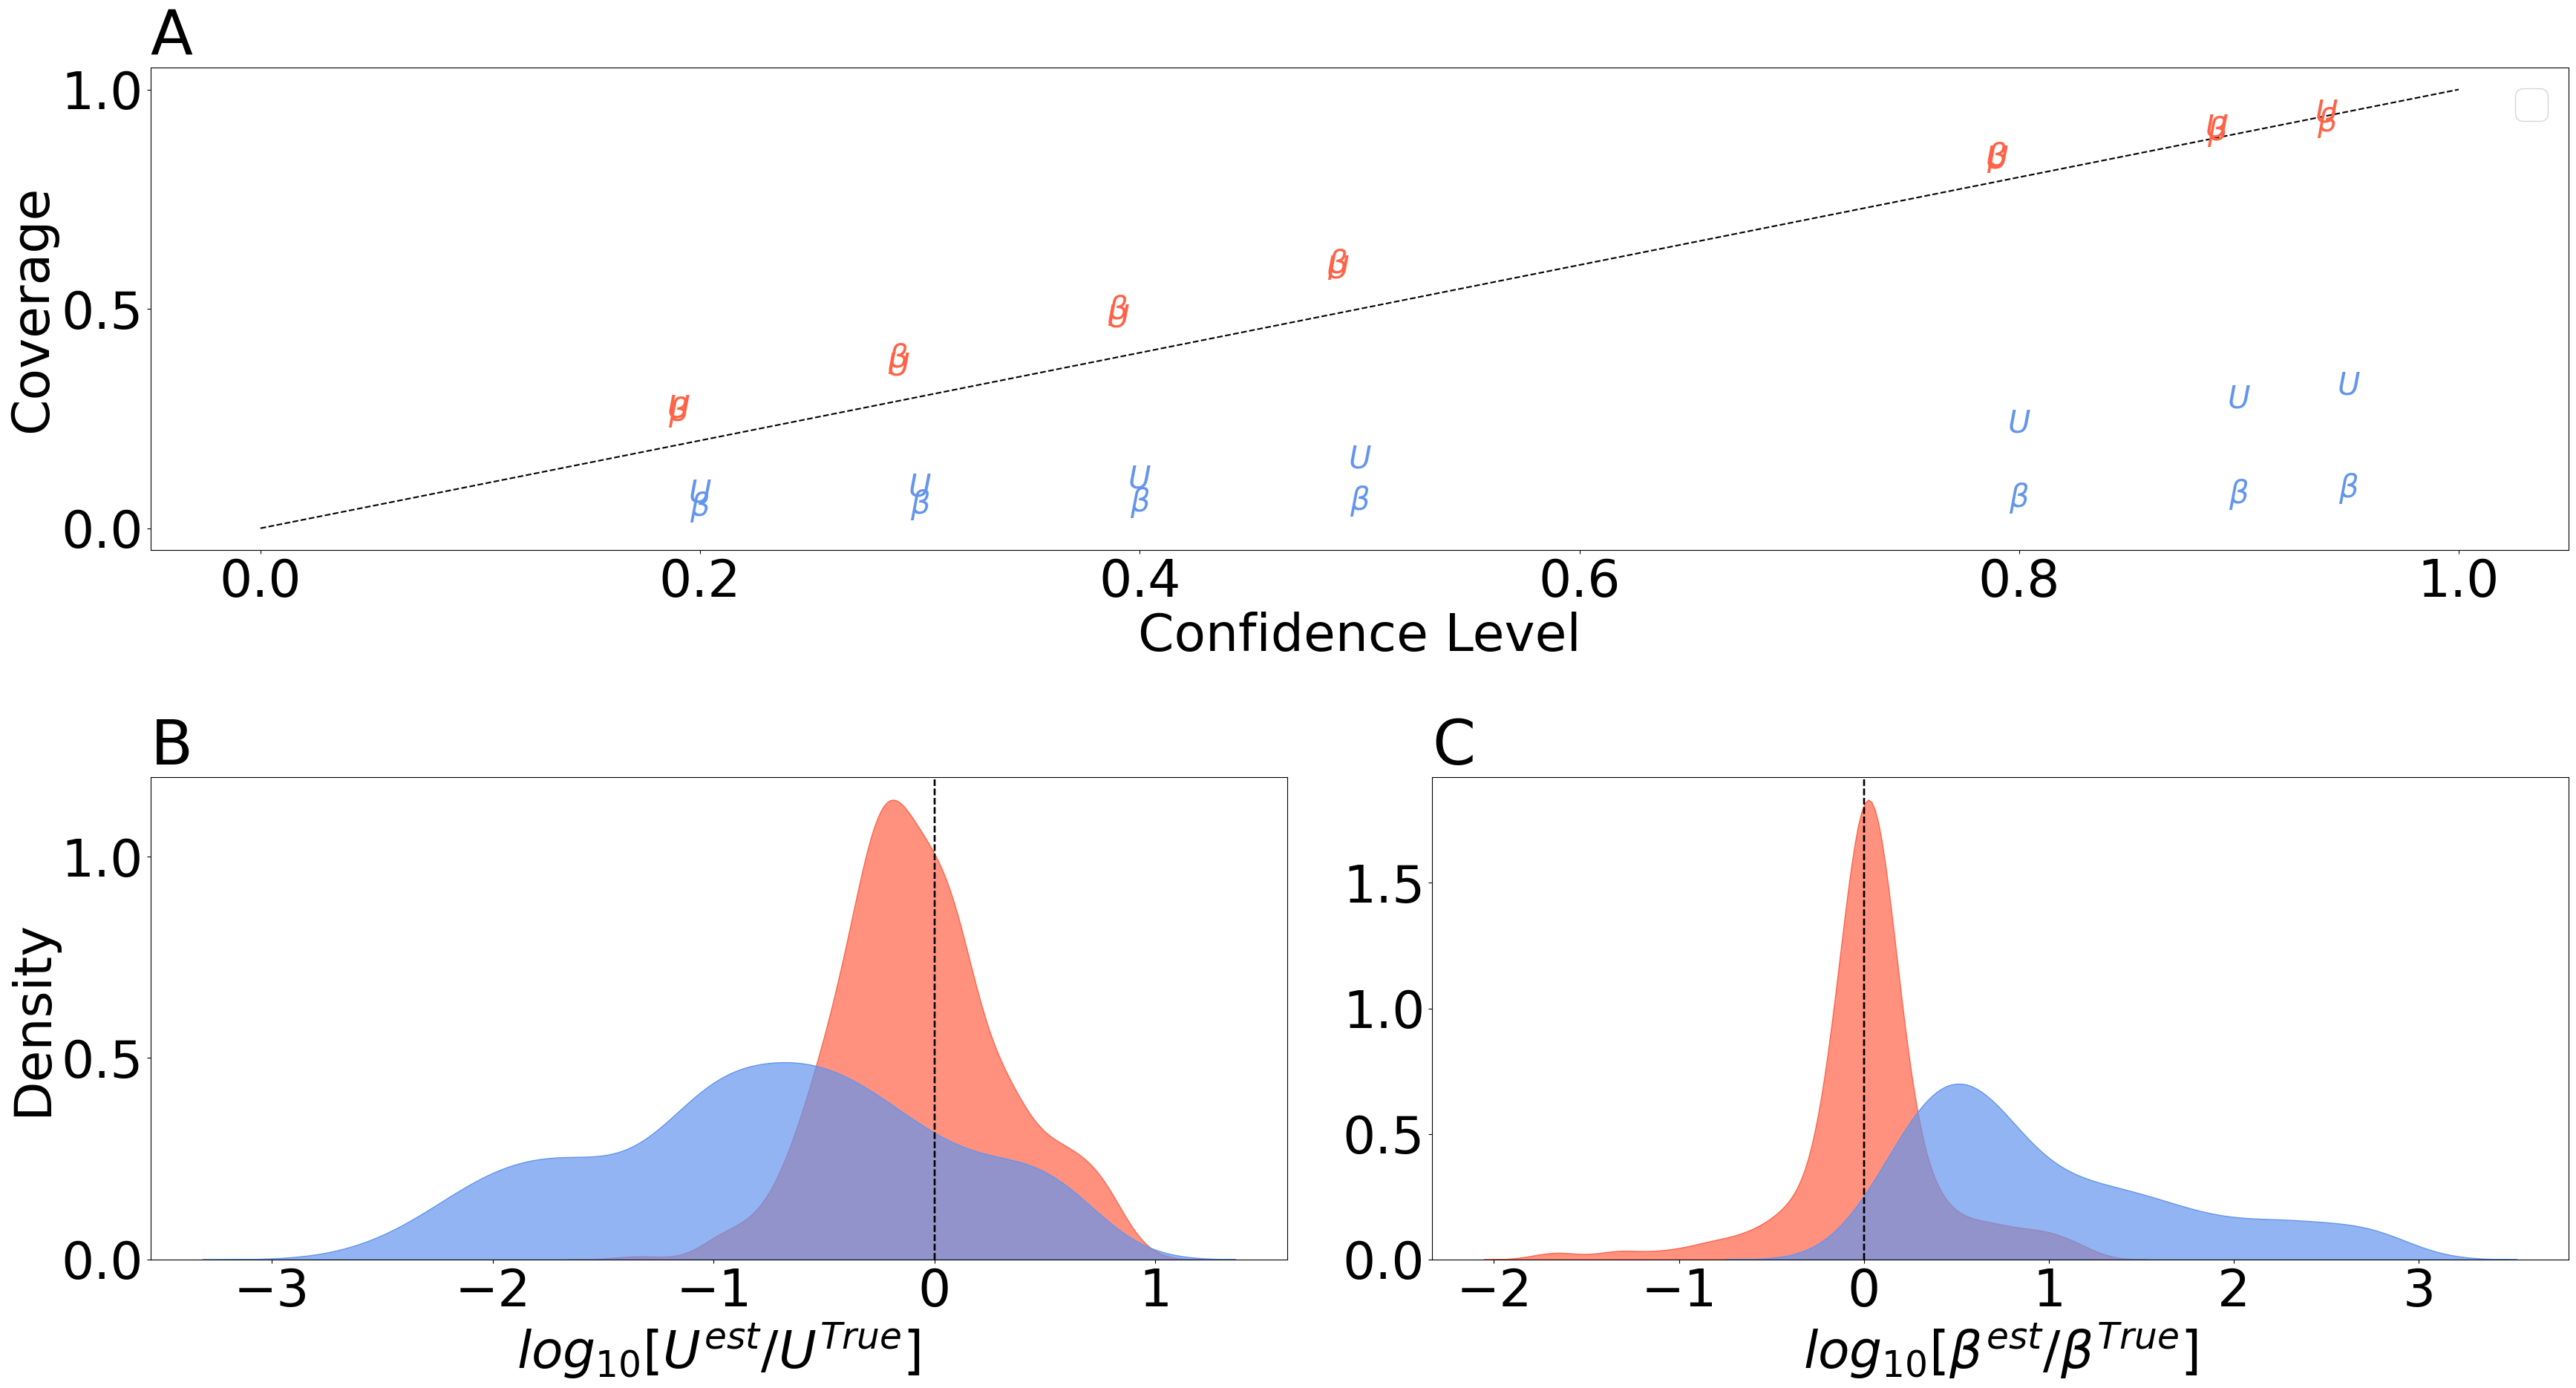

In [19]:
# A - Coverage plots
# B-D - Accuracy plots
mosaic = '''AA
            BC
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')


# Coverage plots in ax B
ax['A'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_GORDO_h_r_.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_,label='Collective\nPosterior',color='tomato', cp=True)
covs_iid = pd.read_csv(f'tests/covs_old_GORDO_iid_h_r_.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['A'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue')
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
ax['A'].legend(fontsize=40)

# Accuracy plots in ax B-C
n_params=2
ax['B'].set_xlabel('$log_{10}[U^{est} / {U^{True}}]$')
ax['C'].set_xlabel('$log_{10}[\\beta^{est} / {\\beta^{True}}]$')

axx = [ax['B'], ax['C']]

cp_acc = 'tests/accus_GORDO_h_r_.csv'
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = 'tests/accus_GORDO_iid_h_r_.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['C'].set_ylabel('')

In [25]:
logprobs_cp = pd.read_csv('tests/logprobs_GORDO_r_.csv', index_col=0, dtype='float')
logprobs_iid = pd.read_csv('tests/logprobs_GORDO_iid_r_.csv', index_col=0, dtype='float')
print('Regular case:')
print(f'Collective Posterior avg log-prob: {logprobs_cp.mean().values[0]:.2f} +/- {logprobs_cp.std().values[0]:.2f}')
print(f'NPE+PIE avg log-prob: {logprobs_iid.mean().values[0]:.2f} +/- {logprobs_iid.std().values[0]:.2f}')

logprobs_cp = pd.read_csv('tests/logprobs_GORDO_h_r_.csv', index_col=0, dtype='float')
logprobs_iid = pd.read_csv('tests/logprobs_GORDO_iid_h_r_.csv', index_col=0, dtype='float')
print('Hierarchical case:')
print(f'Collective Posterior avg log-prob: {logprobs_cp.mean().values[0]:.2f} +/- {logprobs_cp.std().values[0]:.2f}')
print(f'NPE+PIE avg log-prob: {logprobs_iid.mean().values[0]:.2f} +/- {logprobs_iid.std().values[0]:.2f}')


Regular case:
Collective Posterior avg log-prob: -0.56 +/- 3.44
NPE+PIE avg log-prob: 0.81 +/- 1.70
Hierarchical case:
Collective Posterior avg log-prob: -0.58 +/- 3.09
NPE+PIE avg log-prob: -87.38 +/- 101.89


Text(0, 0.5, '')

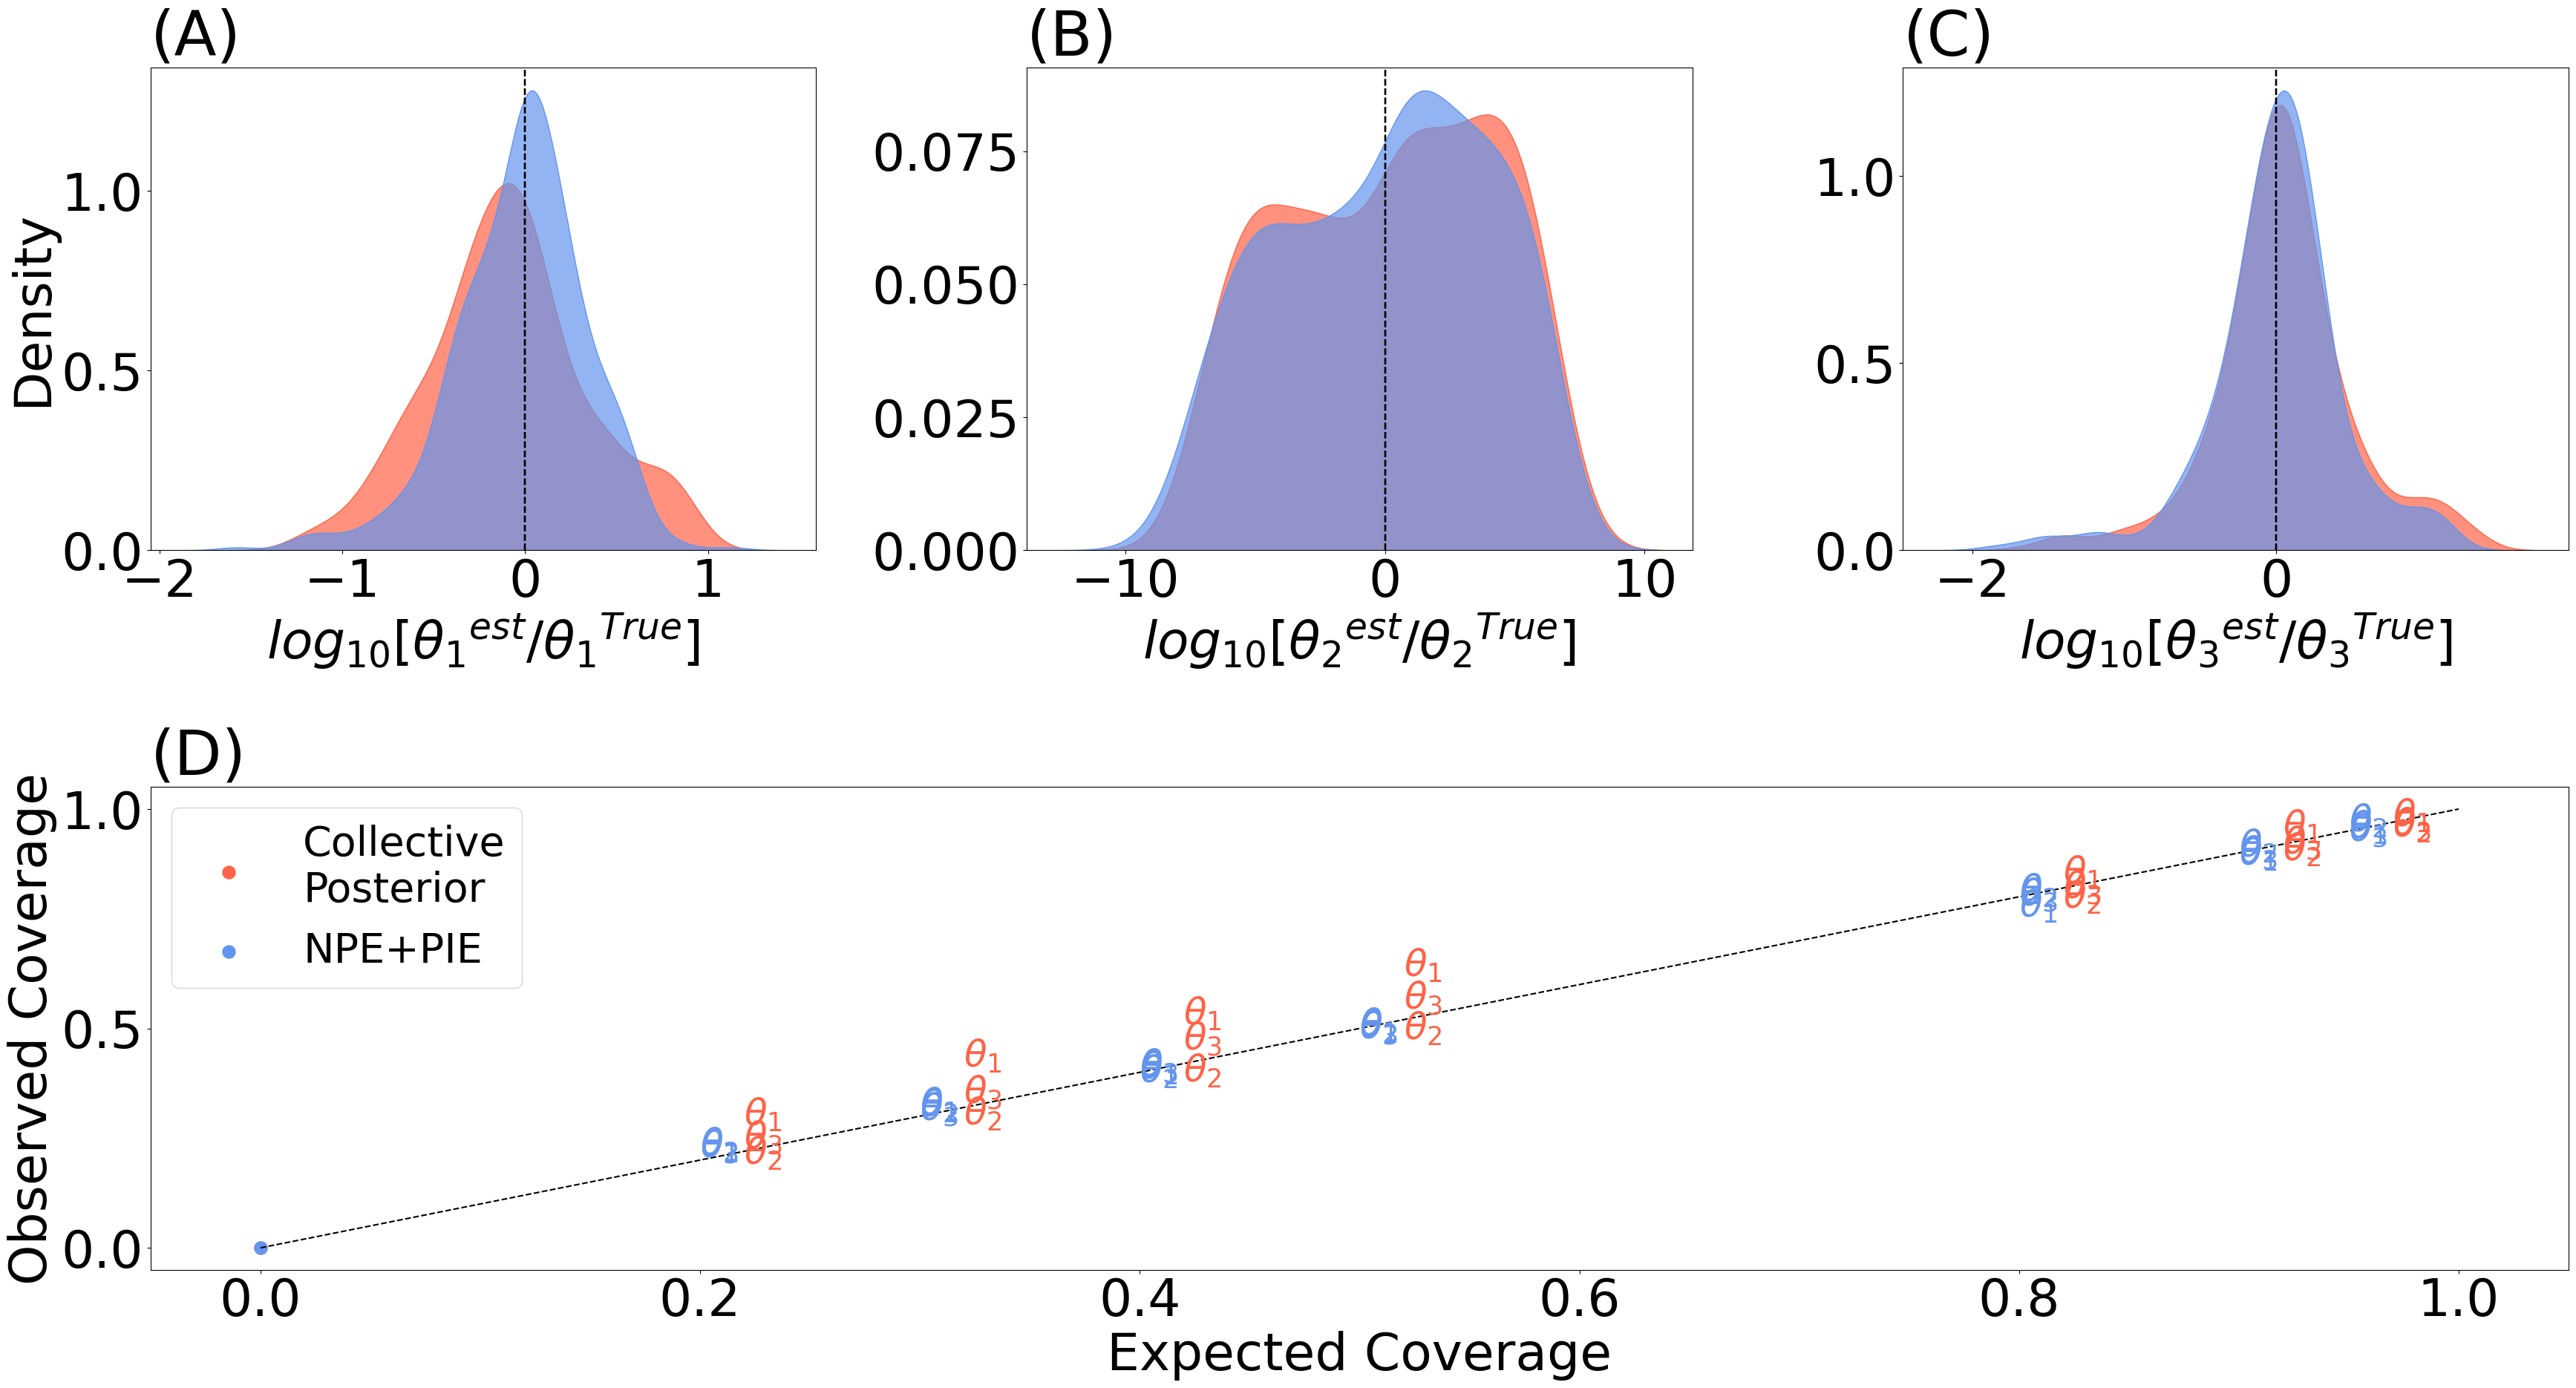

In [ ]:
change_font(50)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        # histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=10, label=label, hatch=hatch)
        kdeplot(res[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs_old(ax, covs, color, label, cp=True):
    param_names = ['$θ_1$', '$θ_2$', '$θ_3$']
    adjust=0.02 if cp else 0
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=200)
            ax.text(covs.index[j]+adjust, covs[p].values[j], word, fontsize=36, color=color)
    ax.scatter(0,0,s=150, label=label, color=color)
        
        

mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('(A)',loc='left')
ax['B'].set_title('(B)',loc='left')
ax['C'].set_title('(C)',loc='left')
ax['D'].set_title('(D)',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_GORDO_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_,label='Collective\nPosterior',color='tomato')
covs_iid = pd.read_csv(f'tests/covs_old_GORDO_iid_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue', cp=False)
# covs = pd.read_csv(f'tests/covs_old_GORDO_m.csv', index_col=0, dtype='float')
# plot_covs_old(ax=ax['D'], covs=covs,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[{θ_1}^{est} / {{θ_1}^{True}}]$')
ax['B'].set_xlabel('$log_{10}[{θ_2}^{est} / {{θ_2}^{True}}]$')
ax['C'].set_xlabel('$log_{10}[{θ_3}^{est} / {{θ_3}^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_GORDO_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

# cp_acc_m = 'tests/accus_GORDO_m.csv'
# plot_accuracy(cp_acc_m, axx, color='maroon', hatch='///', label='')

iid_acc = 'tests/accus_GORDO_iid_h_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['D'].legend(fontsize=40)
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_GORDO_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

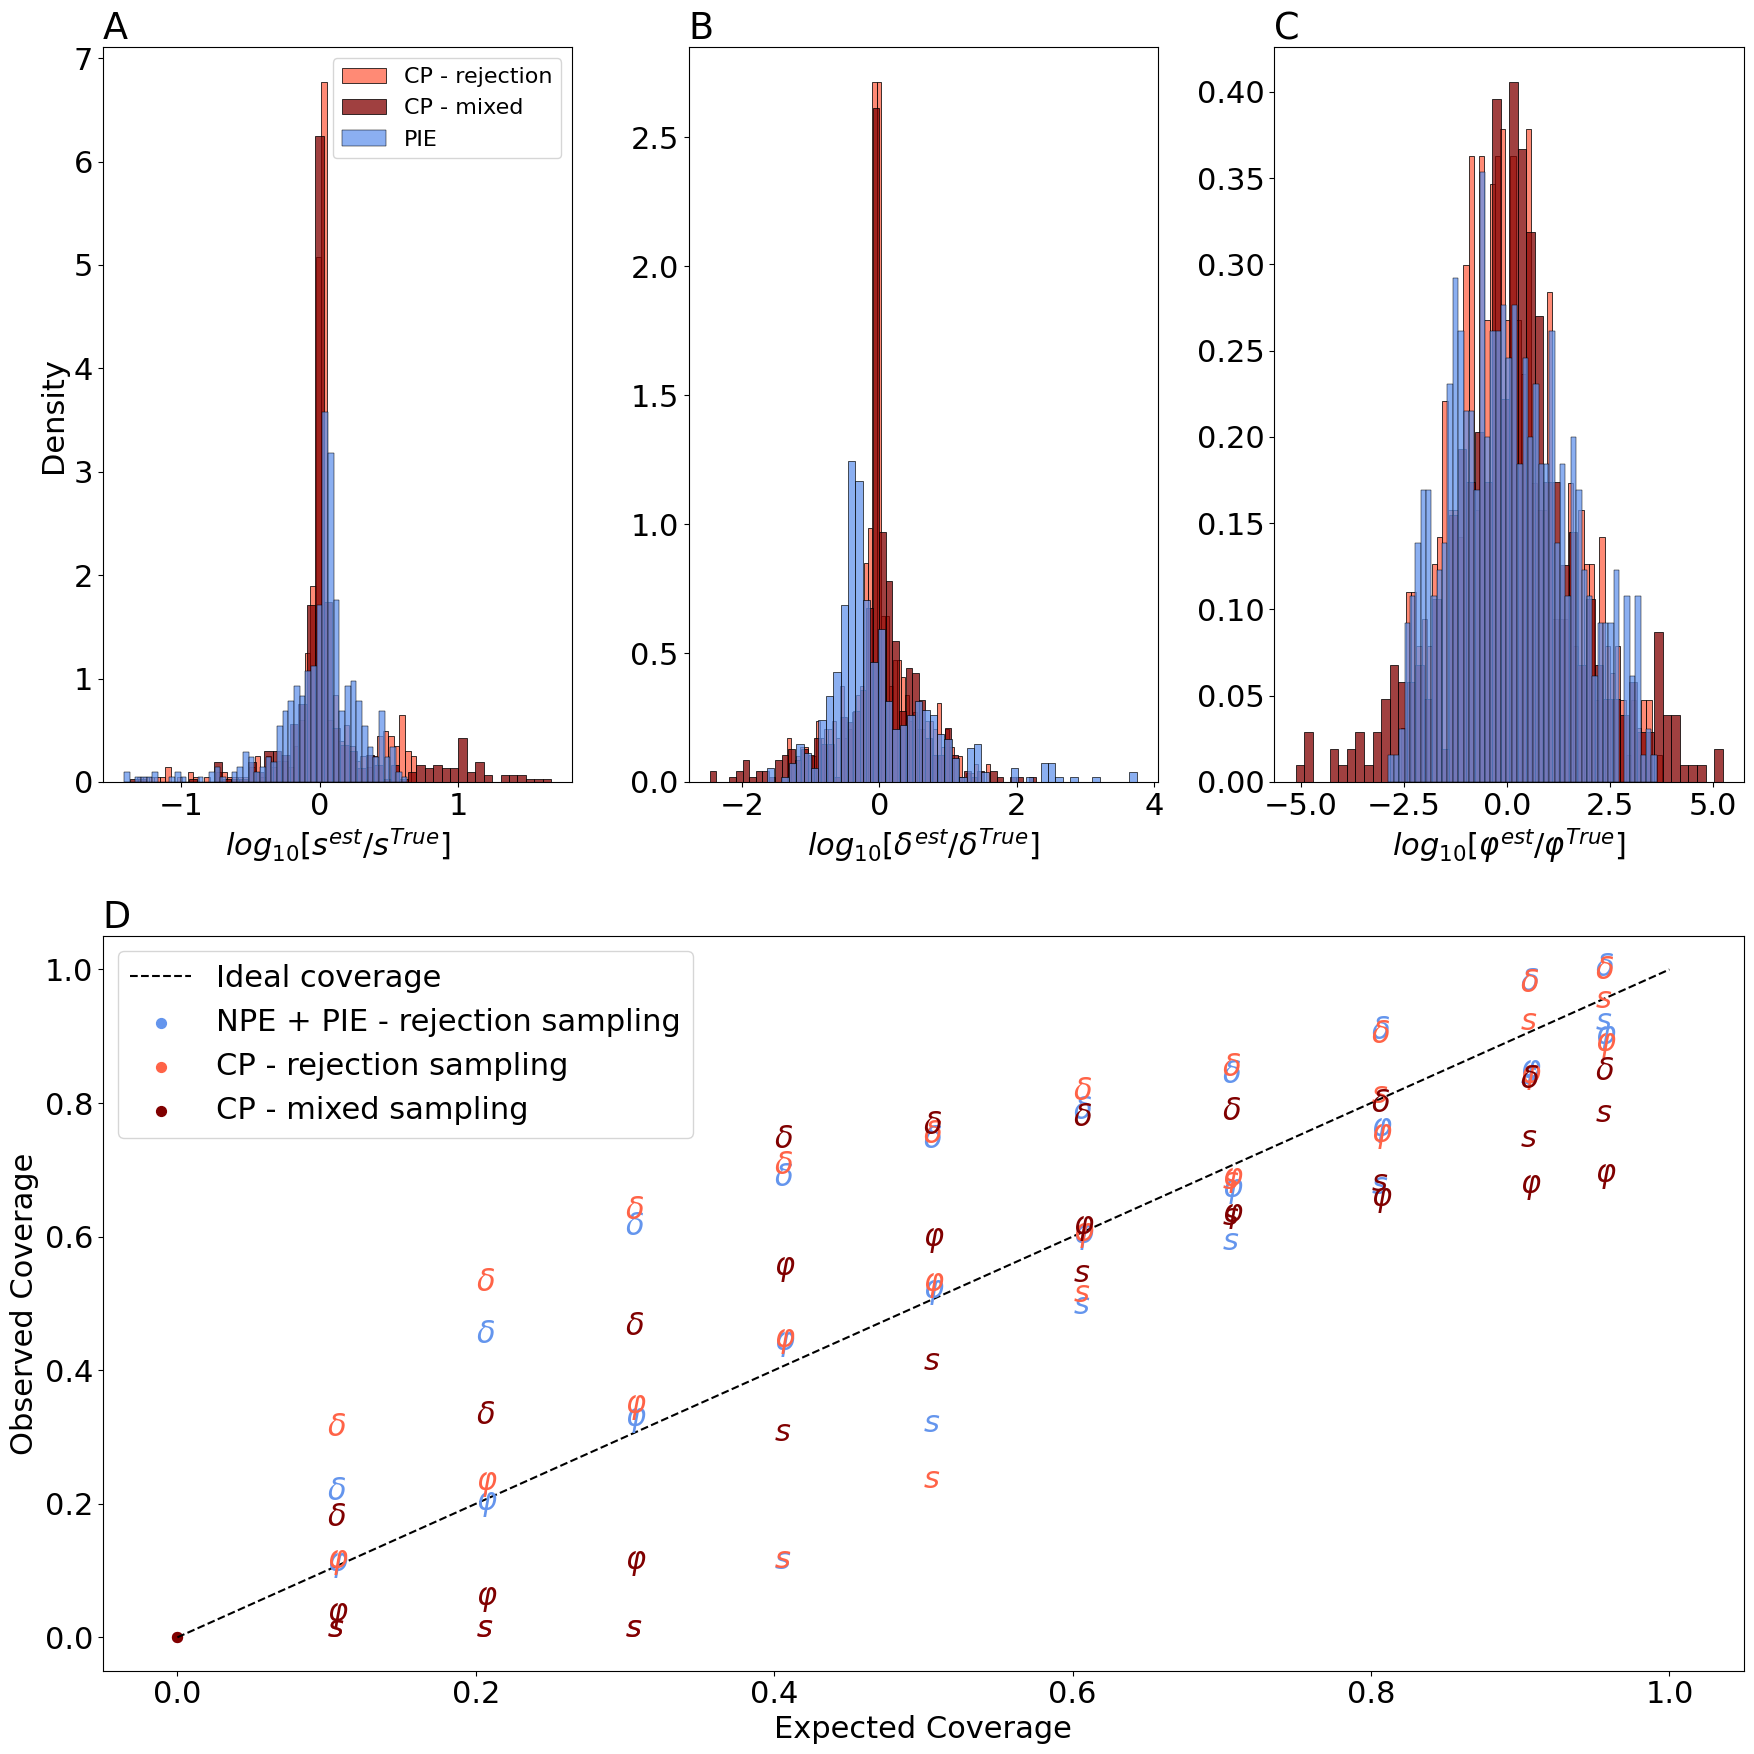

In [ ]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE - rejection sampling',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='CP - rejection sampling',color='tomato')
plot_covs_old(ax=ax['D'], covs=covs_cp_m,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_GORDO_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='CP - rejection')

cp_m_acc = 'tests/accus_WF_m.csv'
plot_accuracy(cp_m_acc, axx, color='maroon', hatch='', label='CP - mixed')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='PIE')

ax['A'].legend(loc='upper right', fontsize=16)
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

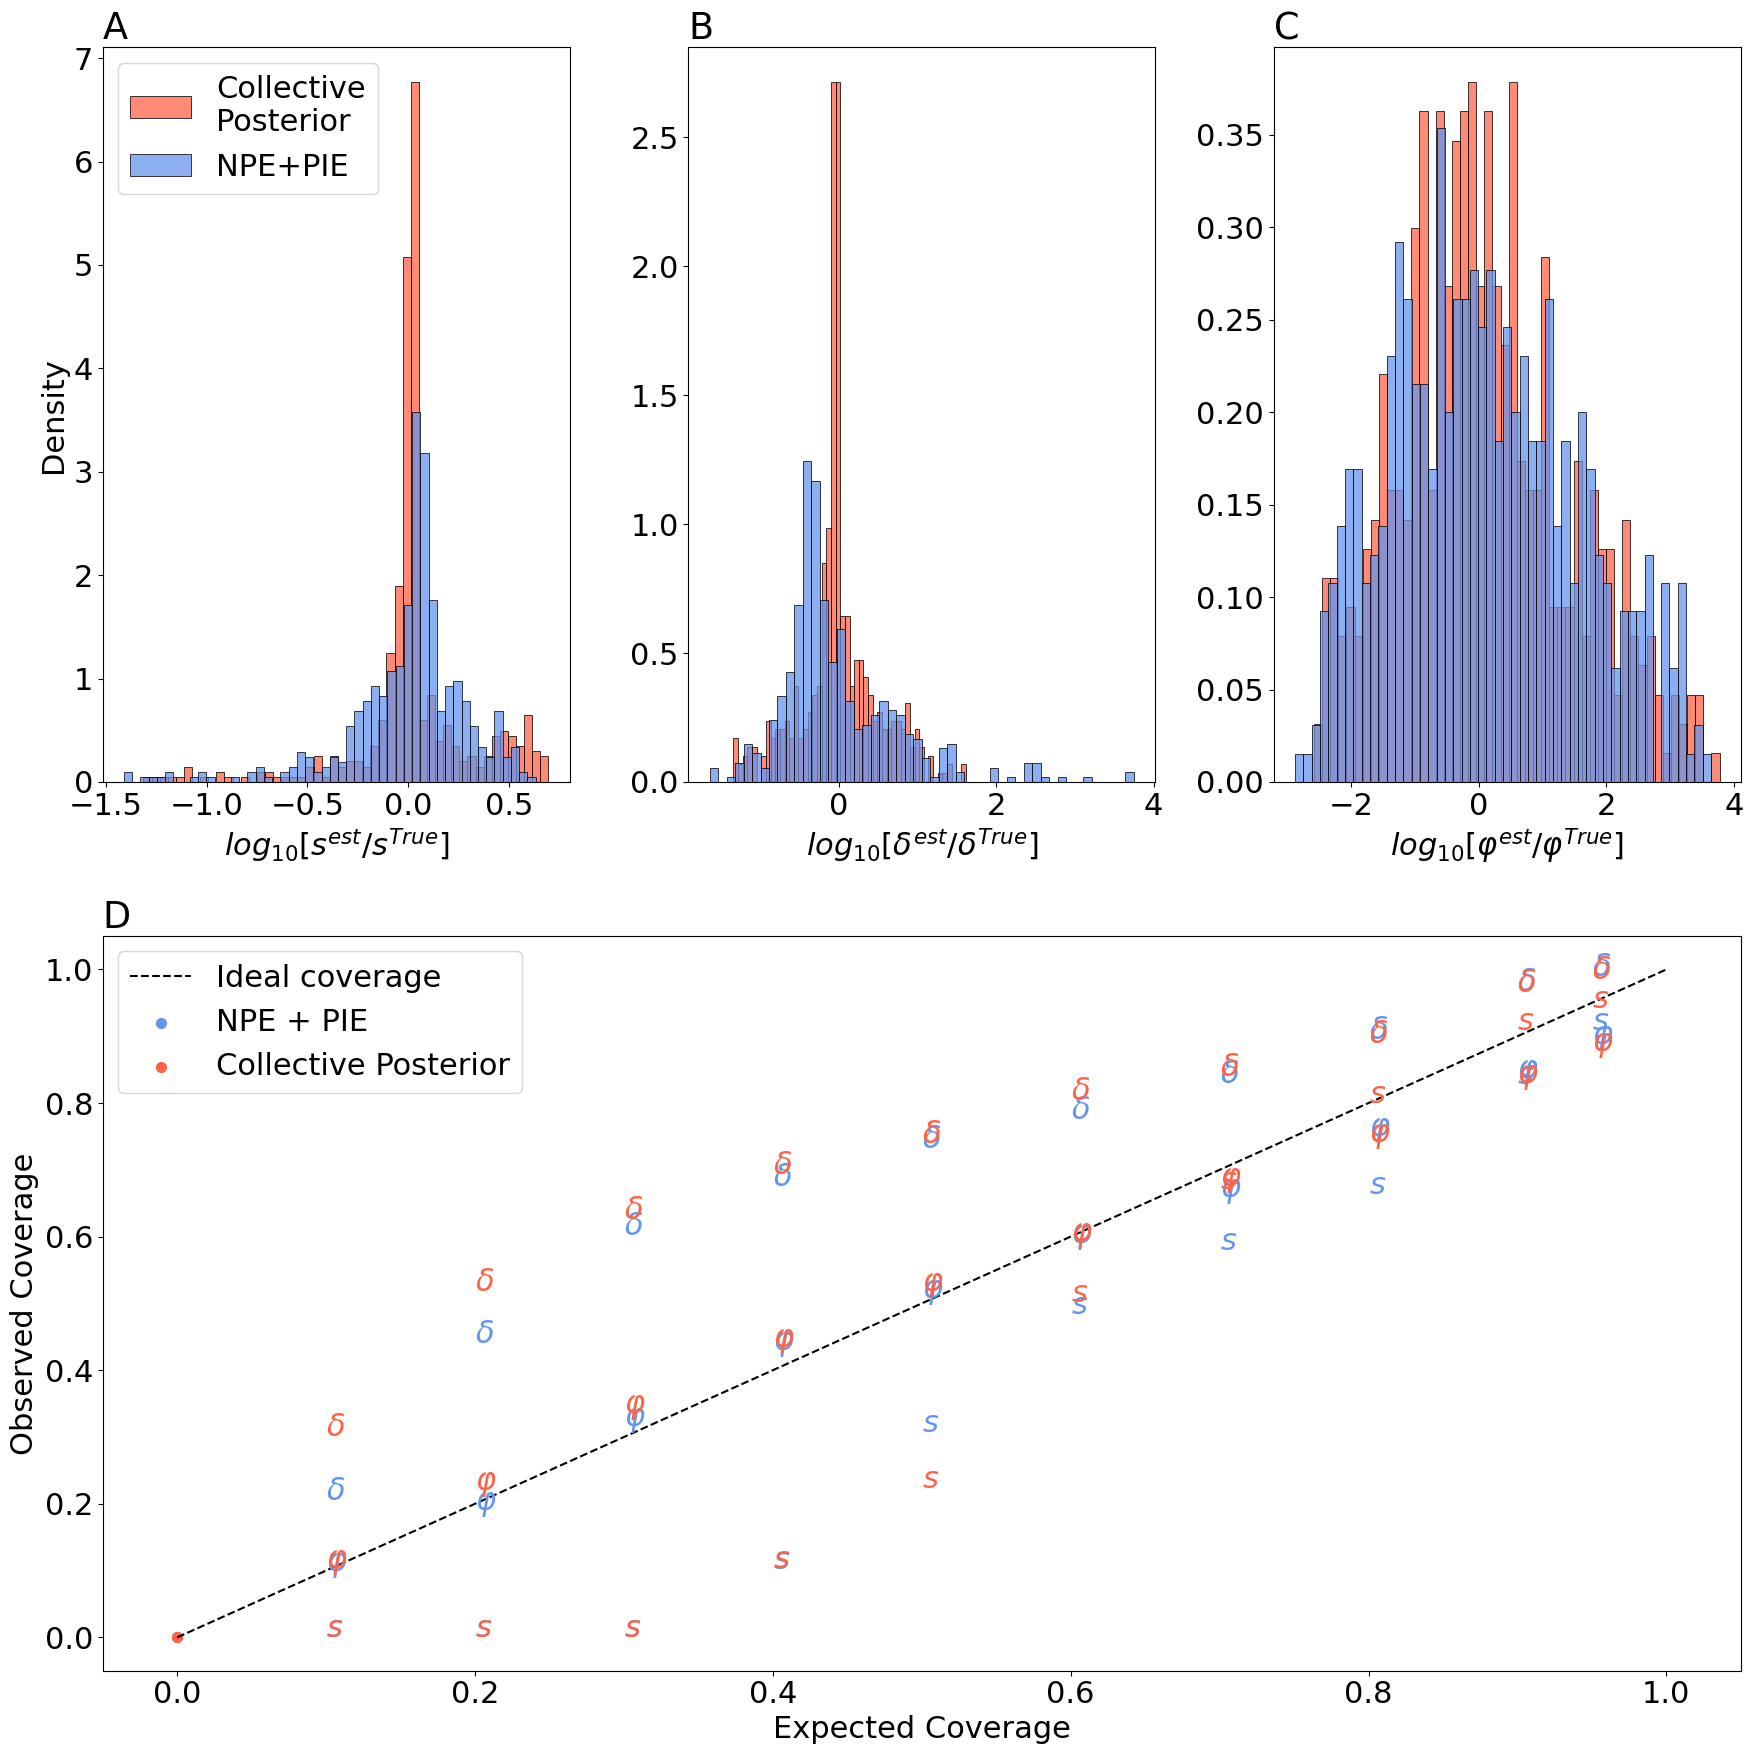

In [15]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='Collective Posterior',color='tomato')


n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['A'].legend()
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



In [29]:
thetas = pd.read_csv('tests/test_thetas.csv', index_col=0)
thetas = torch.from_numpy(np.array(thetas))

cpa = pd.read_csv(cp_acc, index_col=0)
cpa = torch.from_numpy(np.array(cpa))
print(cpa.median(0))
iida = pd.read_csv(iid_acc, index_col=0)
iida = torch.from_numpy(np.array(iida))
print(iida.median(0))

torch.return_types.median(
values=tensor([ 0.0144, -0.0354, -0.0550], dtype=torch.float64),
indices=tensor([119,  11,  95]))
torch.return_types.median(
values=tensor([ 0.0492, -0.2277, -0.0086], dtype=torch.float64),
indices=tensor([ 27,  49, 332]))
